In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\Desktop\fraud-detection-risk-scoring\data\processed\cleaned_creditcard_processed.csv")

In [3]:
df.shape

(283726, 36)

In [4]:
df.isnull().sum()

Time          0
V1            0
V2            0
V3            0
V4            0
V5            0
V6            0
V7            0
V8            0
V9            0
V10           0
V11           0
V12           0
V13           0
V14           0
V15           0
V16           0
V17           0
V18           0
V19           0
V20           0
V21           0
V22           0
V23           0
V24           0
V25           0
V26           0
V27           0
V28           0
Amount        0
Class         0
Hour          0
Day           0
Hour_sin      0
Hour_cos      0
Amount_log    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Hour', 'Day', 'Hour_sin', 'Hour_cos', 'Amount_log'],
      dtype='str')

In [7]:
X = df.drop("Class", axis=1)

In [8]:
X.shape

(283726, 35)

In [9]:
y = df["Class"]

In [10]:
y.shape

(283726,)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (226980, 35)
X_test : (56746, 35)
y_train: (226980,)
y_test : (56746,)


In [14]:
print("Training class distribution:")
print(y_train.value_counts())

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64


In [15]:
print("\nTraining fraud percentage:")
print(y_train.mean() * 100)

print("\nTesting fraud percentage:")
print(y_test.mean() * 100)


Training fraud percentage:
0.16653449643140364

Testing fraud percentage:
0.16741268107003138


In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

In [18]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (226980, 35)
X_test_scaled : (56746, 35)


In [20]:
# calculating class weights to handle class imbalance

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.5008340614822464), np.int64(1): np.float64(300.23809523809524)}


Training Random Forest 

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)

In [23]:
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{np.int64(0): np.float64(0.5008340614822464), np.int64(1): np.float64(300.23809523809524)}"
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of fe

In [24]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [25]:
print("First 20 predictions:")
print(y_pred_rf[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Confusion Matrix

In [26]:
from sklearn.metrics import confusion_matrix

In [27]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[56648     3]
 [   25    70]]


In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

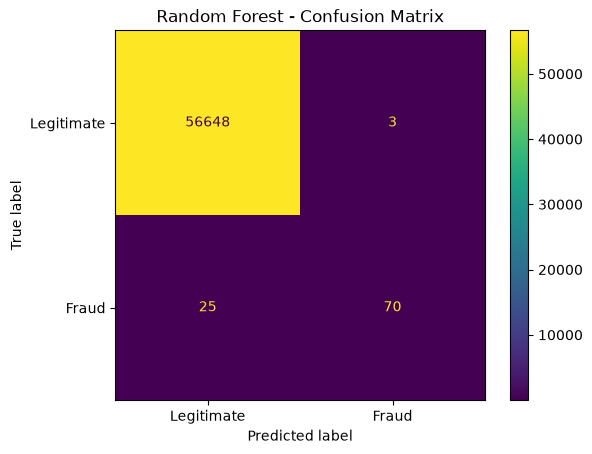

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Legitimate", "Fraud"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [30]:
from sklearn.metrics import precision_score

precision_rf = precision_score(y_test, y_pred_rf)

print("Random Forest Precision:", precision_rf)

Random Forest Precision: 0.958904109589041


In [31]:
from sklearn.metrics import recall_score

recall_rf = recall_score(y_test, y_pred_rf)

print("Random Forest Recall:", recall_rf)

Random Forest Recall: 0.7368421052631579


In [32]:
from sklearn.metrics import f1_score

f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest F1 Score:", f1_rf)

Random Forest F1 Score: 0.8333333333333334


In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.96      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [34]:
rf_results = {
    "Model": "Random Forest",
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1 Score": f1_rf
}

print(rf_results)

{'Model': 'Random Forest', 'Precision': 0.958904109589041, 'Recall': 0.7368421052631579, 'F1 Score': 0.8333333333333334}


SVM (Support Vector Machine).

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [36]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        class_weight=class_weight_dict,
        kernel="rbf",
        random_state=42
    ))
])

In [37]:
svm_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['Time','V1','V2',...,'Hour_sin','Hour_cos','Amount_log']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [38]:
y_pred_svm = svm_pipeline.predict(X_test)

In [39]:
print("First 20 SVM predictions:")
print(y_pred_svm[:20])

First 20 SVM predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Evaluate the SVM

In [40]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

[[56594    57]
 [   30    65]]


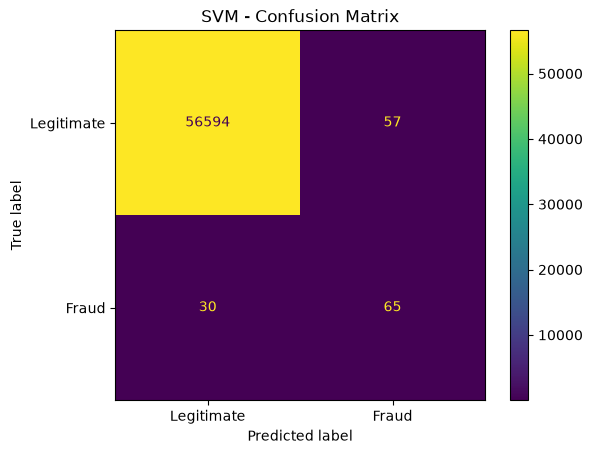

In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=["Legitimate", "Fraud"]
)

plt.title("SVM - Confusion Matrix")
plt.show()

In [42]:
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Precision:", precision_svm)
print("SVM Recall:", recall_svm)
print("SVM F1 Score:", f1_svm)

SVM Precision: 0.5327868852459017
SVM Recall: 0.6842105263157895
SVM F1 Score: 0.5990783410138248


In [43]:
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.53      0.68      0.60        95

    accuracy                           1.00     56746
   macro avg       0.77      0.84      0.80     56746
weighted avg       1.00      1.00      1.00     56746



In [44]:
svm_results = {
    "Model": "SVM",
    "Precision": precision_svm,
    "Recall": recall_svm,
    "F1 Score": f1_svm
}

print(svm_results)

{'Model': 'SVM', 'Precision': 0.5327868852459017, 'Recall': 0.6842105263157895, 'F1 Score': 0.5990783410138248}


Gradient Boosting

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

In [46]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [47]:
sample_weights = y_train.map(class_weight_dict)

In [48]:
print(sample_weights.value_counts())

Class
0.500834      226602
300.238095       378
Name: count, dtype: int64


In [49]:
gb_model.fit(
    X_train_scaled,
    y_train,
    sample_weight=sample_weights
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [51]:
y_pred_gb = gb_model.predict(X_test_scaled)

In [52]:
print("First 20 Gradient Boosting predictions:")
print(y_pred_gb[:20])

First 20 Gradient Boosting predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [53]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

print(cm_gb)

[[56300   351]
 [   16    79]]


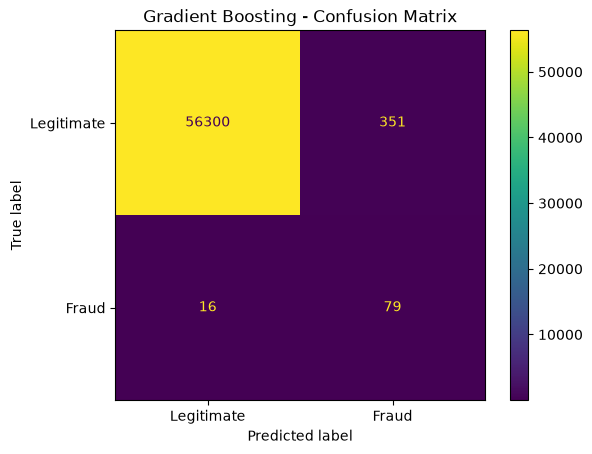

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    display_labels=["Legitimate", "Fraud"]
)

plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

In [55]:
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Precision:", precision_gb)
print("Gradient Boosting Recall:", recall_gb)
print("Gradient Boosting F1 Score:", f1_gb)

Gradient Boosting Precision: 0.18372093023255814
Gradient Boosting Recall: 0.8315789473684211
Gradient Boosting F1 Score: 0.30095238095238097


In [56]:
print(classification_report(
    y_test,
    y_pred_gb,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56651
       Fraud       0.18      0.83      0.30        95

    accuracy                           0.99     56746
   macro avg       0.59      0.91      0.65     56746
weighted avg       1.00      0.99      1.00     56746



In [57]:
gb_results = {
    "Model": "Gradient Boosting",
    "Precision": precision_gb,
    "Recall": recall_gb,
    "F1 Score": f1_gb
}

print(gb_results)

{'Model': 'Gradient Boosting', 'Precision': 0.18372093023255814, 'Recall': 0.8315789473684211, 'F1 Score': 0.30095238095238097}


In [58]:
results_df = pd.DataFrame([
    rf_results,
    svm_results,
    gb_results
])

results_df

,Model,Precision,Recall,F1 Score
0,Random Forest,0.958904,0.736842,0.833333
1,SVM,0.532787,0.684211,0.599078
2,Gradient Boosting,0.183721,0.831579,0.300952


In [59]:
results_df["Precision"] = results_df["Precision"] * 100
results_df["Recall"] = results_df["Recall"] * 100
results_df["F1 Score"] = results_df["F1 Score"] * 100

results_df

,Model,Precision,Recall,F1 Score
0,Random Forest,95.890411,73.684211,83.333333
1,SVM,53.278689,68.421053,59.907834
2,Gradient Boosting,18.372093,83.157895,30.095238


Cross-Validation

In [60]:
from sklearn.model_selection import StratifiedKFold

In [61]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

CV for random forest 

In [62]:
rf_cv_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)

In [63]:
from sklearn.model_selection import cross_validate

In [64]:
rf_cv_results = cross_validate(
    rf_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["precision", "recall", "f1"],
    n_jobs=-1
)

In [65]:
print("Random Forest Cross-Validation")
print("Mean Precision:", rf_cv_results["test_precision"].mean())
print("Mean Recall:", rf_cv_results["test_recall"].mean())
print("Mean F1:", rf_cv_results["test_f1"].mean())

Random Forest Cross-Validation
Mean Precision: 0.9293636630734194
Mean Recall: 0.7856842105263158
Mean F1: 0.8498623616299049


SVM Cross-Validation Using Pipeline

In [66]:
svm_cv_results = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["precision", "recall", "f1"],
    n_jobs=-1
)

In [67]:
print("SVM Cross-Validation")
print("Mean Precision:", svm_cv_results["test_precision"].mean())
print("Mean Recall:", svm_cv_results["test_recall"].mean())
print("Mean F1:", svm_cv_results["test_f1"].mean())

SVM Cross-Validation
Mean Precision: 0.6017506023183884
Mean Recall: 0.7116491228070176
Mean F1: 0.6508066295268021


Gradient Boosting Cross-Validation

In [68]:
gb_cv_precision = []
gb_cv_recall = []
gb_cv_f1 = []

In [69]:
from sklearn.base import clone

In [70]:
for train_idx, val_idx in cv.split(X_train, y_train):

    X_cv_train = X_train.iloc[train_idx]
    X_cv_val = X_train.iloc[val_idx]

    y_cv_train = y_train.iloc[train_idx]
    y_cv_val = y_train.iloc[val_idx]

    # Get class weights for only this fold's training data
    fold_sample_weights = y_cv_train.map(class_weight_dict)

    # Create a fresh model
    gb_cv_model = clone(gb_model)

    # Train
    gb_cv_model.fit(
        X_cv_train,
        y_cv_train,
        sample_weight=fold_sample_weights
    )

    # Predict validation fold
    y_cv_pred = gb_cv_model.predict(X_cv_val)

    # Calculate metrics
    gb_cv_precision.append(
        precision_score(y_cv_val, y_cv_pred)
    )

    gb_cv_recall.append(
        recall_score(y_cv_val, y_cv_pred)
    )

    gb_cv_f1.append(
        f1_score(y_cv_val, y_cv_pred)
    )

In [71]:
print("Gradient Boosting Cross-Validation")
print("Mean Precision:", np.mean(gb_cv_precision))
print("Mean Recall:", np.mean(gb_cv_recall))
print("Mean F1:", np.mean(gb_cv_f1))

Gradient Boosting Cross-Validation
Mean Precision: 0.22123863838099433
Mean Recall: 0.883578947368421
Mean F1: 0.3531032936615047


Create the CV comparison DataFrame

In [72]:
cv_results_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SVM",
        "Gradient Boosting"
    ],
    "Mean Precision": [
        rf_cv_results["test_precision"].mean(),
        svm_cv_results["test_precision"].mean(),
        np.mean(gb_cv_precision)
    ],
    "Mean Recall": [
        rf_cv_results["test_recall"].mean(),
        svm_cv_results["test_recall"].mean(),
        np.mean(gb_cv_recall)
    ],
    "Mean F1": [
        rf_cv_results["test_f1"].mean(),
        svm_cv_results["test_f1"].mean(),
        np.mean(gb_cv_f1)
    ]
})

cv_results_df

,Model,Mean Precision,Mean Recall,Mean F1
0,Random Forest,0.929364,0.785684,0.849862
1,SVM,0.601751,0.711649,0.650807
2,Gradient Boosting,0.221239,0.883579,0.353103


In [73]:
cv_results_df[["Mean Precision", "Mean Recall", "Mean F1"]] *= 100

cv_results_df

,Model,Mean Precision,Mean Recall,Mean F1
0,Random Forest,92.936366,78.568421,84.986236
1,SVM,60.175060,71.164912,65.080663
2,Gradient Boosting,22.123864,88.357895,35.310329


Hyperparameter Tuning

In [74]:
from sklearn.model_selection import GridSearchCV

Tune Random Forest

In [75]:
rf_tuning = RandomForestClassifier(
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [76]:
rf_grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [77]:
rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx

In [78]:
print("Random Forest tuning completed.")

Random Forest tuning completed.


In [79]:
print("Best Parameters:")
print(rf_grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [80]:
print("Best CV F1 Score:", rf_grid_search.best_score_)
print("Best CV F1 Score (%):", rf_grid_search.best_score_ * 100)

Best CV F1 Score: 0.8593463779960245
Best CV F1 Score (%): 85.93463779960246


In [ ]:
tuned_rf = rf_grid_search.best_estimator_

In [82]:
print(tuned_rf)

RandomForestClassifier(class_weight={np.int64(0): np.float64(0.5008340614822464),
                                     np.int64(1): np.float64(300.23809523809524)},
                       max_depth=20, n_jobs=-1, random_state=42)


In [83]:
print("Best Parameters:")
print(rf_grid_search.best_params_)

print("Best CV F1 Score:", rf_grid_search.best_score_)
print("Best CV F1 Score (%):", rf_grid_search.best_score_ * 100)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 Score: 0.8593463779960245
Best CV F1 Score (%): 85.93463779960246


Evaluate the Tuned Random Forest

In [84]:
y_pred_tuned_rf = tuned_rf.predict(X_test)

In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tuned_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [86]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_tuned_rf = precision_score(
    y_test,
    y_pred_tuned_rf
)

recall_tuned_rf = recall_score(
    y_test,
    y_pred_tuned_rf
)

f1_tuned_rf = f1_score(
    y_test,
    y_pred_tuned_rf
)

print("Tuned RF Precision:", precision_tuned_rf)
print("Tuned RF Recall:", recall_tuned_rf)
print("Tuned RF F1 Score:", f1_tuned_rf)

print()
print("Tuned RF Precision (%):", precision_tuned_rf * 100)
print("Tuned RF Recall (%):", recall_tuned_rf * 100)
print("Tuned RF F1 Score (%):", f1_tuned_rf * 100)

Tuned RF Precision: 0.9583333333333334
Tuned RF Recall: 0.7263157894736842
Tuned RF F1 Score: 0.8263473053892215

Tuned RF Precision (%): 95.83333333333334
Tuned RF Recall (%): 72.63157894736842
Tuned RF F1 Score (%): 82.63473053892216


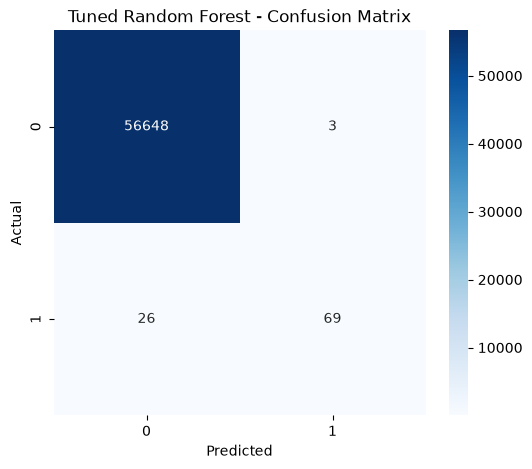

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_tuned_rf = confusion_matrix(
    y_test,
    y_pred_tuned_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Precision-Recall Curve & Threshold Tuning

In [88]:
y_proba_tuned_rf = tuned_rf.predict_proba(X_test)[:, 1]

In [89]:
print(y_proba_tuned_rf[:10])

[0.         0.         0.         0.         0.00998637 0.
 0.         0.         0.         0.        ]


In [90]:
y_pred_tuned_rf = tuned_rf.predict(X_test)

In [91]:
threshold = 0.50

y_pred_threshold_50 = (
    y_proba_tuned_rf >= threshold
).astype(int)

In [92]:
print(
    "Predictions same:",
    (y_pred_threshold_50 == y_pred_tuned_rf).all()
)

Predictions same: True


In [93]:
precision_50 = precision_score(
    y_test,
    y_pred_threshold_50
)

recall_50 = recall_score(
    y_test,
    y_pred_threshold_50
)

f1_50 = f1_score(
    y_test,
    y_pred_threshold_50
)

print("Threshold:", threshold)
print("Precision:", precision_50 * 100)
print("Recall:", recall_50 * 100)
print("F1 Score:", f1_50 * 100)

Threshold: 0.5
Precision: 95.83333333333334
Recall: 72.63157894736842
F1 Score: 82.63473053892216


Generate the Precision-Recall Curve

In [94]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_proba_tuned_rf
)

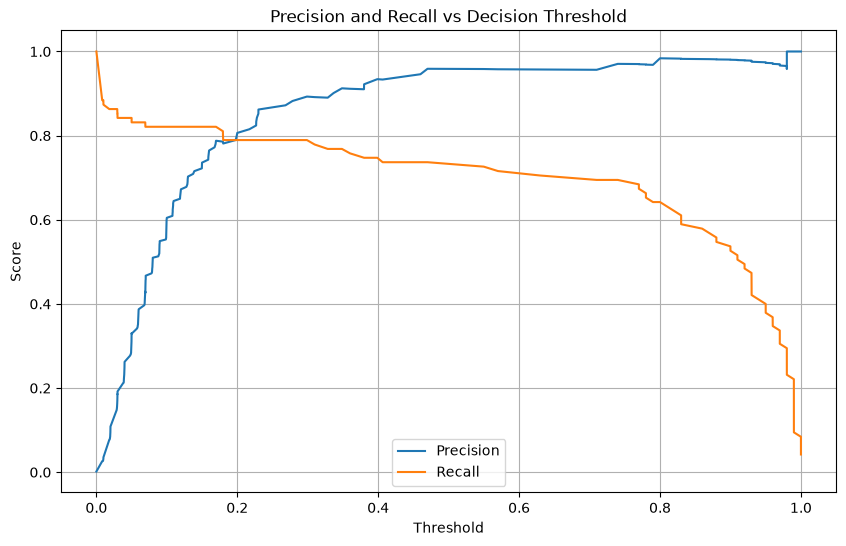

In [95]:
plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precision_values[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recall_values[:-1],
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Decision Threshold")
plt.legend()
plt.grid()
plt.show()

Test Different Thresholds

In [96]:
thresholds_to_test = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = []

for threshold in thresholds_to_test:

    y_pred = (
        y_proba_tuned_rf >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1 Score": f1 * 100
    })

In [97]:
threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df

,Threshold,Precision,Recall,F1 Score
0,0.1,60.937500,82.105263,69.955157
1,0.2,81.521739,78.947368,80.213904
2,0.3,89.156627,77.894737,83.146067
3,0.4,93.333333,73.684211,82.352941
4,0.5,95.833333,72.631579,82.634731
5,0.6,95.714286,70.526316,81.212121
6,0.7,95.652174,69.473684,80.487805
7,0.8,98.360656,63.157895,76.923077
8,0.9,98.000000,51.578947,67.586207


In [98]:
y_proba_tuned_rf

array([0., 0., 0., ..., 0., 0., 0.], shape=(56746,))

In [99]:
risk_scores = y_proba_tuned_rf * 100

In [100]:
print(risk_scores[:10])

[0.         0.         0.         0.         0.99863667 0.
 0.         0.         0.         0.        ]


Create a risk-level function

In [101]:
def get_risk_level(score):

    if score < 30:
        return "Low Risk"

    elif score < 70:
        return "Medium Risk"

    else:
        return "High Risk"

In [102]:
risk_demo = pd.DataFrame({
    "Fraud Probability": y_proba_tuned_rf[:20],
    "Risk Score": risk_scores[:20]
})

risk_demo["Risk Level"] = risk_demo["Risk Score"].apply(
    get_risk_level
)

risk_demo

,Fraud Probability,Risk Score,Risk Level
0,0.000000,0.000000,Low Risk
1,0.000000,0.000000,Low Risk
2,0.000000,0.000000,Low Risk
3,0.000000,0.000000,Low Risk
4,0.009986,0.998637,Low Risk
5,0.000000,0.000000,Low Risk
6,0.000000,0.000000,Low Risk
7,0.000000,0.000000,Low Risk
8,0.000000,0.000000,Low Risk
9,0.000000,0.000000,Low Risk


Evaluate the Final Model with ROC-AUC and PR-AUC

In [103]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_proba_tuned_rf
)

print("ROC-AUC:", roc_auc)
print("ROC-AUC (%):", roc_auc * 100)

ROC-AUC: 0.9379089327173118
ROC-AUC (%): 93.79089327173118


In [104]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test,
    y_proba_tuned_rf
)

print("PR-AUC:", pr_auc)
print("PR-AUC (%):", pr_auc * 100)

PR-AUC: 0.8084215223940062
PR-AUC (%): 80.84215223940062


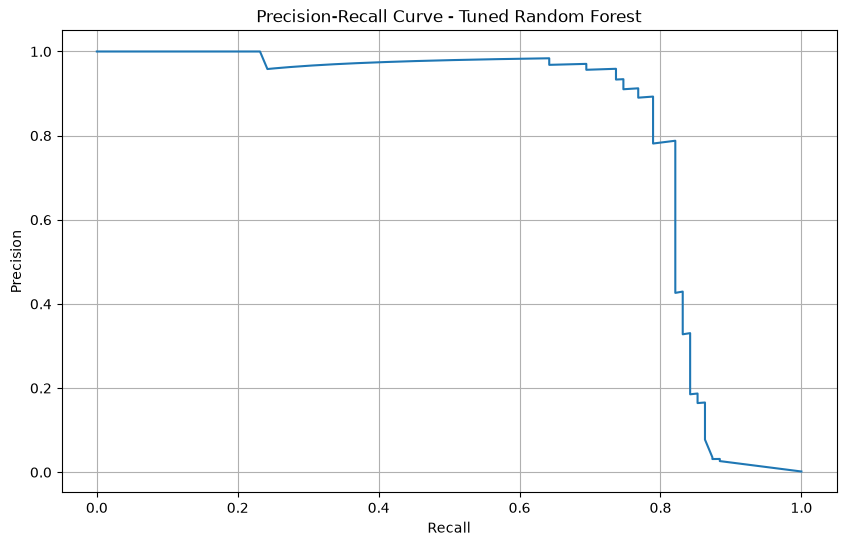

In [105]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_proba_tuned_rf
)

plt.figure(figsize=(10, 6))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned Random Forest")
plt.grid()

plt.show()

In [106]:
final_rf_metrics = {
    "Model": "Tuned Random Forest",
    "Precision": precision_tuned_rf,
    "Recall": recall_tuned_rf,
    "F1 Score": f1_tuned_rf,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

final_rf_metrics

{'Model': 'Tuned Random Forest',
 'Precision': 0.9583333333333334,
 'Recall': 0.7263157894736842,
 'F1 Score': 0.8263473053892215,
 'ROC-AUC': 0.9379089327173118,
 'PR-AUC': 0.8084215223940062}

In [107]:
import joblib

In [108]:
joblib.dump(
    tuned_rf,
    "../models/random_forest_fraud_model.pkl"
)

['../models/random_forest_fraud_model.pkl']

In [109]:
import os

model_path = "../models/random_forest_fraud_model.pkl"

print("Model exists:", os.path.exists(model_path))

Model exists: True


In [110]:
loaded_rf = joblib.load(
    "../models/random_forest_fraud_model.pkl"
)

print(type(loaded_rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [111]:
loaded_predictions = loaded_rf.predict(X_test)

print(
    "Predictions identical:",
    (loaded_predictions == y_pred_tuned_rf).all()
)

Predictions identical: True


Predictions identical: True

In [112]:
feature_names = X_train.columns.tolist()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 35
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'Day', 'Hour_sin', 'Hour_cos', 'Amount_log']


In [113]:
joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

['../models/feature_names.pkl']

In [114]:
feature_path = "../models/feature_names.pkl"

print(
    "Feature file exists:",
    os.path.exists(feature_path)
)

Feature file exists: True


In [115]:
loaded_features = joblib.load(
    "../models/feature_names.pkl"
)

print("Number of loaded features:", len(loaded_features))
print("Features identical:", loaded_features == feature_names)


Number of loaded features: 35
Features identical: True


In [116]:
import numpy as np
import pandas as pd


def engineer_features(transaction_df):
    """
    Apply the same feature engineering used during model training.
    """

    df_input = transaction_df.copy()

    # Time-based features
    df_input["Hour"] = (
        df_input["Time"] // 3600
    ) % 24

    df_input["Day"] = (
        df_input["Time"] // 86400
    ).astype(int)

    # Cyclical encoding of hour
    df_input["Hour_sin"] = np.sin(
        2 * np.pi * df_input["Hour"] / 24
    )

    df_input["Hour_cos"] = np.cos(
        2 * np.pi * df_input["Hour"] / 24
    )

    # Log transformation of transaction amount
    df_input["Amount_log"] = np.log1p(
        df_input["Amount"]
    )

    return df_input

In [117]:
sample_transaction = df.drop(
    columns=["Class"]
).iloc[[0]].copy()

In [118]:
sample_transaction

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Hour,Day,Hour_sin,Hour_cos,Amount_log
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0,0,0.0,1.0,5.01476


In [119]:
sample_engineered = engineer_features(
    sample_transaction
)

print(
    "Shape:",
    sample_engineered.shape
)

print(
    sample_engineered.columns.tolist()
)

Shape: (1, 35)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'Day', 'Hour_sin', 'Hour_cos', 'Amount_log']


In [120]:
print(
    "Correct feature order:",
    sample_engineered.columns.tolist() == feature_names
)

Correct feature order: True


In [121]:
sample_prediction = loaded_rf.predict(
    sample_engineered
)

sample_probability = loaded_rf.predict_proba(
    sample_engineered
)[:, 1]

print("Prediction:", sample_prediction[0])
print(
    "Fraud Probability:",
    sample_probability[0]
)

Prediction: 0
Fraud Probability: 0.0


In [122]:
sample_risk_score = (
    sample_probability[0] * 100
)

print(
    "Risk Score:",
    sample_risk_score
)

Risk Score: 0.0


In [123]:
sample_risk_level = get_risk_level(
    sample_risk_score
)

print(
    "Risk Level:",
    sample_risk_level
)

Risk Level: Low Risk


In [124]:
import sys

sys.path.append("../api")

In [125]:
from preprocessing import engineer_features

In [126]:
sample_engineered_api = engineer_features(
    sample_transaction
)

print(
    "Shape:",
    sample_engineered_api.shape
)

print(
    "Correct feature order:",
    sample_engineered_api.columns.tolist() == feature_names
)

Shape: (1, 35)
Correct feature order: True


In [127]:
api_prediction = loaded_rf.predict(
    sample_engineered_api
)

api_probability = loaded_rf.predict_proba(
    sample_engineered_api
)[:, 1]

api_risk_score = api_probability[0] * 100

api_risk_level = get_risk_level(
    api_risk_score
)

print("Prediction:", api_prediction[0])
print("Fraud Probability:", api_probability[0])
print("Risk Score:", api_risk_score)
print("Risk Level:", api_risk_level)

Prediction: 0
Fraud Probability: 0.0
Risk Score: 0.0
Risk Level: Low Risk


In [128]:
import sys

if "../api" not in sys.path:
    sys.path.append("../api")

In [129]:
from model_service import predict_transaction

In [130]:
test_transaction = (
    df.drop(columns=["Class"])
      .iloc[0]
      .to_dict()
)

In [131]:
test_result = predict_transaction(
    test_transaction
)

test_result

{'prediction': 0,
 'fraud_probability': 0.0,
 'risk_score': 0.0,
 'risk_level': 'Low Risk'}

In [132]:
print("Prediction:", test_result["prediction"])
print(
    "Fraud Probability:",
    test_result["fraud_probability"]
)
print(
    "Risk Score:",
    test_result["risk_score"]
)
print(
    "Risk Level:",
    test_result["risk_level"]
)

Prediction: 0
Fraud Probability: 0.0
Risk Score: 0.0
Risk Level: Low Risk


In [133]:
fraud_sample = df[
    df["Class"] == 1
].drop(columns=["Class"]).iloc[0]

fraud_sample

Time          406.000000
V1             -2.312227
V2              1.951992
V3             -1.609851
V4              3.997906
V5             -0.522188
V6             -1.426545
V7             -2.537387
V8              1.391657
V9             -2.770089
V10            -2.772272
V11             3.202033
V12            -2.899907
V13            -0.595222
V14            -4.289254
V15             0.389724
V16            -1.140747
V17            -2.830056
V18            -0.016822
V19             0.416956
V20             0.126911
V21             0.517232
V22            -0.035049
V23            -0.465211
V24             0.320198
V25             0.044519
V26             0.177840
V27             0.261145
V28            -0.143276
Amount          0.000000
Hour            0.000000
Day             0.000000
Hour_sin        0.000000
Hour_cos        1.000000
Amount_log      0.000000
Name: 534, dtype: float64

In [134]:
fraud_json = fraud_sample.to_dict()

fraud_json

{'Time': 406.0,
 'V1': -2.3122265423263,
 'V2': 1.95199201064158,
 'V3': -1.60985073229769,
 'V4': 3.9979055875468,
 'V5': -0.522187864667764,
 'V6': -1.42654531920595,
 'V7': -2.53738730624579,
 'V8': 1.39165724829804,
 'V9': -2.77008927719433,
 'V10': -2.77227214465915,
 'V11': 3.20203320709635,
 'V12': -2.89990738849473,
 'V13': -0.595221881324605,
 'V14': -4.28925378244217,
 'V15': 0.389724120274487,
 'V16': -1.14074717980657,
 'V17': -2.83005567450437,
 'V18': -0.0168224681808257,
 'V19': 0.416955705037907,
 'V20': 0.126910559061474,
 'V21': 0.517232370861764,
 'V22': -0.0350493686052974,
 'V23': -0.465211076182388,
 'V24': 0.320198198514526,
 'V25': 0.0445191674731724,
 'V26': 0.177839798284401,
 'V27': 0.261145002567677,
 'V28': -0.143275874698919,
 'Amount': 0.0,
 'Hour': 0.0,
 'Day': 0.0,
 'Hour_sin': 0.0,
 'Hour_cos': 1.0,
 'Amount_log': 0.0}